# Scenario Epsilon

Scenario epsilon asks you to hold the pollutant load arriving at a treatment
plant below a threshold. Here we search for a single fixed valve setting per
controlled asset using Bayesian optimization, treating one full simulation as
one evaluation of an expensive black box function.


In [ ]:
!pip install scikit-optimize pystorms

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pystorms
from skopt import gp_minimize
from skopt.plots import plot_convergence

plt.rcParams.update({"font.size": 14})
plt.style.use("seaborn-v0_8-whitegrid")

## How many valves are we tuning?

Ask the scenario rather than hard coding the number, so the search space always
matches the network.

In [3]:
env = pystorms.scenarios.epsilon()
n_actions = len(env.env.config["action_space"])
env.env.terminate()

print(f"epsilon exposes {n_actions} controlled assets")

epsilon exposes 11 controlled assets


## Objective function

One call runs the scenario end to end and returns its performance measure.
`gp_minimize` minimizes, and lower performance is better here, so we can return
it directly.

In [4]:
def f_loss(x):
    env = pystorms.scenarios.epsilon()
    done = False
    while not done:
        done = env.step(np.asarray(x, dtype=float))
    return env.performance()

## Search

Twenty evaluations, the first five drawn at random to seed the surrogate. Each
one is a full simulation, so this takes a couple of minutes.

In [5]:
result = gp_minimize(
    f_loss,
    dimensions=[(0.0, 1.0)] * n_actions,
    acq_func="EI",
    n_calls=20,
    n_initial_points=5,
    random_state=42,
)

print(f"best performance : {result.fun:.1f}")
print(f"best settings    : {np.round(result.x, 3)}")

best performance : 1727.8
best settings    : [0.394 0.586 0.672 0.166 0.634 0.426 0.057 0.16  0.    0.895 0.115]


## Did it beat leaving the valves open?

In [6]:
uncontrolled = f_loss(np.ones(n_actions))

print(f"uncontrolled : {uncontrolled:.1f}")
print(f"optimized    : {result.fun:.1f}")
print(f"improvement  : {100 * (uncontrolled - result.fun) / uncontrolled:.1f}%")

uncontrolled : 7688.4
optimized    : 1727.8
improvement  : 77.5%


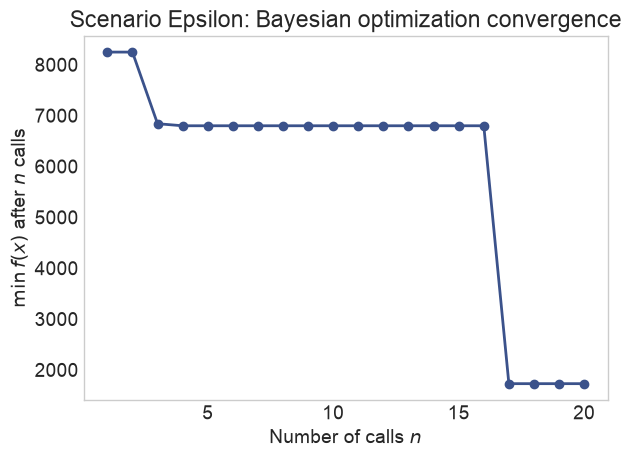

In [7]:
plot_convergence(result)
plt.title("Scenario Epsilon: Bayesian optimization convergence")
plt.tight_layout()

## Exercise

The search above tunes a single static setting per valve. Try making the
objective time varying, for example by switching between two settings on a
depth threshold, and see whether the extra freedom pays for the larger search
space.